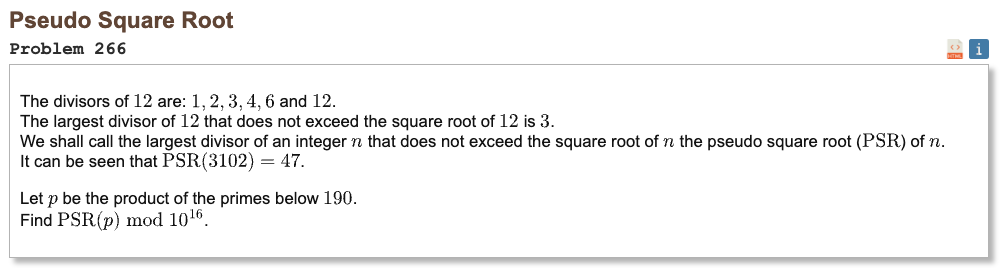

## Initial approach

* Since n is the product of distinct primes, every divisor is made by choosing a subset of these primes and multiplying them.
* So the pseudo square root is the biggest subset product that is not larger than the integer square root of n.
* There are 42 primes below 190, so we split them into two halves of 21 primes.
* We list all subset products of the second half, sort them, then for each subset product of the first half we binary search the best matching product that stays under the limit.
* The best product we find is the pseudo square root, then we output it modulo 10^16.

In [1]:
import math
import bisect

def primes_below(limit: int) -> list[int]:
    if limit <= 2:
        return []
    sieve = bytearray(b"\x01") * limit
    sieve[0:2] = b"\x00\x00"
    r = int(limit ** 0.5)
    for i in range(2, r + 1):
        if sieve[i]:
            step = i
            start = i * i
            sieve[start:limit:step] = b"\x00" * (((limit - 1 - start) // step) + 1)
    return [i for i in range(limit) if sieve[i]]

def subset_products(values: list[int]) -> list[int]:
    products = [1]
    for v in values:
        products += [x * v for x in products]
    return products

def solve() -> int:
    primes = primes_below(190)
    n_value = 1
    for p in primes:
        n_value *= p
    target = math.isqrt(n_value)

    left = primes[:21]
    right = primes[21:]

    right_products = subset_products(right)
    right_products.sort()

    best = 0
    left_products = subset_products(left)

    for a in left_products:
        limit = target // a
        idx = bisect.bisect_right(right_products, limit) - 1
        if idx >= 0:
            candidate = a * right_products[idx]
            if candidate > best:
                best = candidate

    return best % (10 ** 16)

In [2]:
%%time
print(solve())

1096883702440585
CPU times: user 1.82 s, sys: 44.4 ms, total: 1.87 s
Wall time: 1.87 s
